# Prepare

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt

2026-03-02 04:08:15.925414: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772424495.950720     394 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772424495.958266     394 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772424495.978022     394 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772424495.978045     394 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772424495.978047     394 computation_placer.cc:177] computation placer alr

In [3]:
img = tf.io.read_file("/kaggle/input/datasets/weipengzhang/adobe-fivek/raw/a0001-jmac_DSC1459.jpg")
img = tf.image.decode_jpeg(img)

I0000 00:00:1772424506.091137     394 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


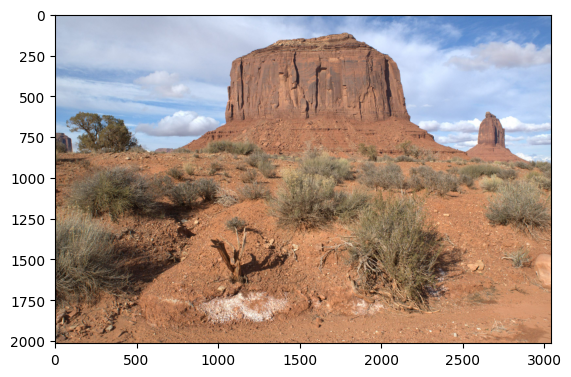

In [4]:
plt.imshow(img)

In [5]:
IMG_SIZE = 224

In [6]:
img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

In [7]:
img = img / 255.0

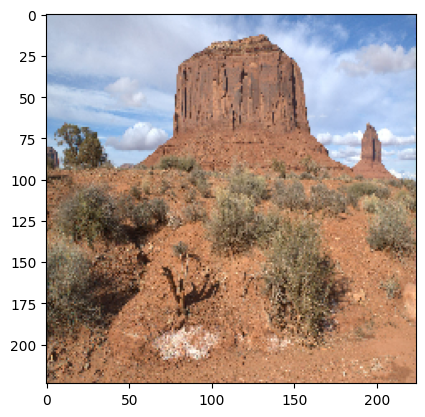

In [8]:
plt.imshow(img)

# Tonecurve filters

## Luminance tone curve

In [9]:
def luma_curve(imgs, lut):
    K = tf.shape(lut)[1]

    LUMA = tf.constant([0.2126, 0.7155, 0.0722], dtype=tf.float32)
    luminance = tf.reduce_sum(imgs * LUMA, axis=-1, keepdims=True)

    u = luminance * tf.cast(K - 1, tf.float32)
    i = tf.cast(u, tf.int32)
    j = tf.clip_by_value(i + 1, 0, K - 1)

    lut_i = tf.gather(lut, i, batch_dims=1)
    lut_j = tf.gather(lut, j, batch_dims=1)

    w = u - tf.cast(i, tf.float32)
    luminance_new = (1 - w) * lut_i + w * lut_j

    eps = 1e-4
    scale = luminance_new / tf.maximum(luminance, eps)
    scale = tf.clip_by_value(scale, 0.0, 10.0)

    imgs = imgs * scale
    imgs = tf.clip_by_value(imgs, 0.0, 1.0)
    return imgs

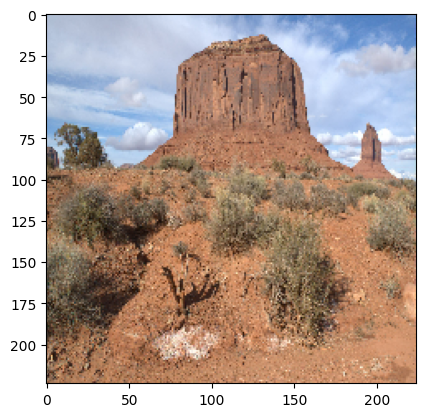

In [10]:
test_luma_lut = tf.constant([0.0, 0.25, 0.5, 0.75, 1.0])

test_luma_img = luma_curve(tf.stack([img]), tf.stack([test_luma_lut]))[0]

plt.imshow(test_luma_img.numpy())

In [11]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

style = {'description_width': '90px'}

s0 = widgets.FloatSlider(value=0.0, min=0, max=1, step=0.01, description='Shadows', style=style)
s1 = widgets.FloatSlider(value=0.25, min=0, max=1, step=0.01, description='Dark', style=style)
s2 = widgets.FloatSlider(value=0.5, min=0, max=1, step=0.01, description='Mid', style=style)
s3 = widgets.FloatSlider(value=0.75, min=0, max=1, step=0.01, description='Bright', style=style)
s4 = widgets.FloatSlider(value=1.0, min=0, max=1, step=0.01, description='Highlights', style=style)

ui = widgets.VBox([s0, s1, s2, s3, s4])


def update(shadows, dark, mid, bright, highlights):
    lut = tf.constant([shadows, dark, mid, bright, highlights], dtype=tf.float32)

    out = luma_curve(tf.stack([img]), tf.stack([lut]))[0]
    out_np = out.numpy()
    img_np = img.numpy()

    # ---- Plot ----
    plt.figure(figsize=(12, 6))

    # Ảnh trước
    plt.subplot(2, 3, 1)
    plt.title("Before")
    plt.imshow(img_np)
    plt.axis('off')

    # Ảnh sau
    plt.subplot(2, 3, 2)
    plt.title("After")
    plt.imshow(out_np)
    plt.axis('off')

    # Tone curve
    plt.subplot(2, 3, 3)
    x = np.linspace(0, 1, 5)
    y = [shadows, dark, mid, bright, highlights]
    plt.plot(x, y, '-o')
    plt.title("Tone Curve")
    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.grid()

    # Histogram trước
    plt.subplot(2, 3, 4)
    plt.title("Histogram Before")
    plt.hist(img_np.flatten(), bins=50, range=(0,1))

    # Histogram sau
    plt.subplot(2, 3, 5)
    plt.title("Histogram After")
    plt.hist(out_np.flatten(), bins=50, range=(0,1))

    plt.tight_layout()
    plt.show()


out = widgets.interactive_output(
    update,
    {
        'shadows': s0,
        'dark': s1,
        'mid': s2,
        'bright': s3,
        'highlights': s4
    }
)

In [12]:
display(ui, out)

Output()

## Color curve filter

In [13]:
def color_curves(imgs, lut):
    shape = tf.shape(imgs)
    B, H, W, C = shape[0], shape[1], shape[2], shape[3]
    K = tf.shape(lut)[1]

    u = imgs * tf.cast(K - 1, tf.float32)
    i = tf.cast(u, tf.int32)
    j = tf.clip_by_value(i + 1, 0, K - 1)

    batch_idx = tf.range(B)
    batch_idx = tf.reshape(batch_idx, [B, 1, 1, 1])
    batch_idx = tf.tile(batch_idx, [1, H, W, C])

    channel_idx = tf.range(C)
    channel_idx = tf.reshape(channel_idx, [1, 1, 1, C])
    channel_idx = tf.tile(channel_idx, [B, H, W, 1])

    i_nd = tf.stack([batch_idx, i, channel_idx], axis=-1)
    j_nd = tf.stack([batch_idx, j, channel_idx], axis=-1)

    lut_i = tf.gather_nd(lut, i_nd)
    lut_j = tf.gather_nd(lut, j_nd)

    w = u - tf.cast(i, tf.float32)
    out = (1 - w) * lut_i + w * lut_j
    return tf.clip_by_value(out, 0.0, 1.0)

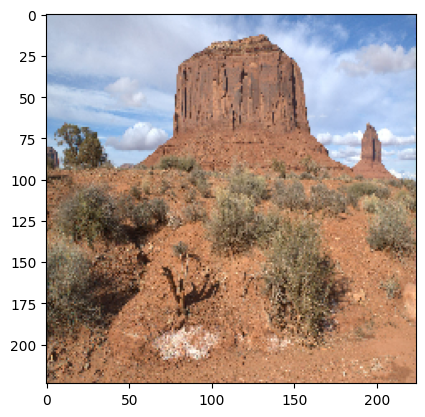

In [14]:
test_color_curves = tf.constant([
    [0.0, 0.0, 0.0], 
    [0.25, 0.25, 0.25],
    [0.5, 0.5, 0.5],
    [0.75, 0.75, 0.75], 
    [1.0, 1.0, 1.0]]
)

test_color_img = color_curves(tf.stack([img]), tf.stack([test_color_curves]))[0]

plt.imshow(test_color_img.numpy())

In [15]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

style = {'description_width': '50px'}
layout = widgets.Layout(width='350px')

def make_channel_sliders(prefix, default):
    return [
        widgets.FloatSlider(value=default[0], min=0, max=1, step=0.01,
                            description=f'{prefix}0', style=style, layout=layout),
        widgets.FloatSlider(value=default[1], min=0, max=1, step=0.01,
                            description=f'{prefix}1', style=style, layout=layout),
        widgets.FloatSlider(value=default[2], min=0, max=1, step=0.01,
                            description=f'{prefix}2', style=style, layout=layout),
        widgets.FloatSlider(value=default[3], min=0, max=1, step=0.01,
                            description=f'{prefix}3', style=style, layout=layout),
        widgets.FloatSlider(value=default[4], min=0, max=1, step=0.01,
                            description=f'{prefix}4', style=style, layout=layout),
    ]

# Default identity curve
default_curve = [0.0, 0.25, 0.5, 0.75, 1.0]

r_sliders = make_channel_sliders('R', default_curve)
g_sliders = make_channel_sliders('G', default_curve)
b_sliders = make_channel_sliders('B', default_curve)

ui = widgets.HBox([
    widgets.VBox([widgets.Label("Red"), *r_sliders]),
    widgets.VBox([widgets.Label("Green"), *g_sliders]),
    widgets.VBox([widgets.Label("Blue"), *b_sliders]),
])

In [16]:
def update(**kwargs):
    # Lấy giá trị theo thứ tự
    values = [kwargs[f'v{i}'] for i in range(15)]

    r_vals = values[0:5]
    g_vals = values[5:10]
    b_vals = values[10:15]

    # Tạo color curve tensor (5,3)
    curve = tf.constant([
        [r_vals[0], g_vals[0], b_vals[0]],
        [r_vals[1], g_vals[1], b_vals[1]],
        [r_vals[2], g_vals[2], b_vals[2]],
        [r_vals[3], g_vals[3], b_vals[3]],
        [r_vals[4], g_vals[4], b_vals[4]],
    ], dtype=tf.float32)

    # Apply color curve
    out = color_curves(tf.stack([img]), tf.stack([curve]))[0]

    img_np = img.numpy()
    out_np = out.numpy()

    # ---- Plot ----
    plt.figure(figsize=(14, 8))

    # Before / After
    plt.subplot(2,3,1)
    plt.title("Before")
    plt.imshow(img_np)
    plt.axis('off')

    plt.subplot(2,3,2)
    plt.title("After")
    plt.imshow(out_np)
    plt.axis('off')

    # Curves
    x = np.linspace(0,1,5)
    plt.subplot(2,3,3)
    plt.plot(x, r_vals, 'r-o', label='R')
    plt.plot(x, g_vals, 'g-o', label='G')
    plt.plot(x, b_vals, 'b-o', label='B')
    plt.title("Color Curves")
    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.grid()
    plt.legend()

    # Histogram BEFORE
    plt.subplot(2,3,4)
    plt.title("Histogram Before")
    plt.hist(img_np[:,:,0].flatten(), bins=50, alpha=0.5, color='r')
    plt.hist(img_np[:,:,1].flatten(), bins=50, alpha=0.5, color='g')
    plt.hist(img_np[:,:,2].flatten(), bins=50, alpha=0.5, color='b')

    # Histogram AFTER
    plt.subplot(2,3,5)
    plt.title("Histogram After")
    plt.hist(out_np[:,:,0].flatten(), bins=50, alpha=0.5, color='r')
    plt.hist(out_np[:,:,1].flatten(), bins=50, alpha=0.5, color='g')
    plt.hist(out_np[:,:,2].flatten(), bins=50, alpha=0.5, color='b')

    plt.tight_layout()
    plt.show()

In [17]:
all_sliders = r_sliders + g_sliders + b_sliders

out = widgets.interactive_output(
    update,
    {f'v{i}': s for i, s in enumerate(all_sliders)}
)

display(ui, out)

Output()

# Dataset

In [18]:
import tensorflow as tf
import os

IMG_SIZE = 224
BATCH_SIZE = 8

raw_dir = "/kaggle/input/datasets/weipengzhang/adobe-fivek/raw"
target_dir = "/kaggle/input/datasets/weipengzhang/adobe-fivek/c"

raw_files = sorted(tf.io.gfile.glob(os.path.join(raw_dir, "*.jpg")))
target_files = [os.path.join(target_dir, os.path.basename(f)) for f in raw_files]

print(len(raw_files))

5000


In [19]:
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img

def parse_pair(raw_path, tgt_path):
    raw = load_image(raw_path)
    tgt = load_image(tgt_path)
    return raw, tgt

In [28]:
dataset = tf.data.Dataset.from_tensor_slices((raw_files, target_files))
dataset = dataset.map(parse_pair, num_parallel_calls=tf.data.AUTOTUNE)

dataset_size = len(raw_files)
test_size = int(0.1 * dataset_size)
train_size = dataset_size - test_size

dataset = dataset.shuffle(buffer_size=dataset_size, reshuffle_each_iteration=False)

train_ds = dataset.take(train_size)
test_ds = dataset.skip(train_size)

train_ds = train_ds.shuffle(1000, reshuffle_each_iteration=True)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [29]:
print(len(train_ds) * BATCH_SIZE, len(test_ds) * BATCH_SIZE)

4504 504


# Model training

In [63]:
class CurveModel(tf.keras.Model):
    def call(self, inputs):
        imgs, luma_lut, color_lut = inputs
        imgs = luma_curve(imgs, luma_lut)
        imgs = color_curves(imgs, color_lut)
        return imgs

K = 5

img_in = tf.keras.Input(shape=(None, None, 3), name="image")
luma_in = tf.keras.Input(shape=(K,), name="luma_lut")
color_in = tf.keras.Input(shape=(K, 3), name="color_lut")

# img_in = tf.keras.Input(shape=(None, None, 3), dtype=tf.float32, name="image")
# luma_in = tf.keras.Input(shape=(None,), dtype=tf.float32, name="luma_lut")
# color_in = tf.keras.Input(shape=(None, 3), dtype=tf.float32, name="color_lut")

curve_model = CurveModel()
curve_out = curve_model([img_in, luma_in, color_in])

curve_model = tf.keras.Model(
    inputs=[img_in, luma_in, color_in],
    outputs=curve_out
)

curve_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, None,      │          0 │ -                 │
│                     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ luma_lut            │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ color_lut           │ (None, 5, 3)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ curve_model_2       │ (None, None,      │          0 │ image[0][0],      │
│ (CurveModel)        │ None, 3)          │            │ luma_lut[0][0],   │
│                     │                   │            │ color_lut[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

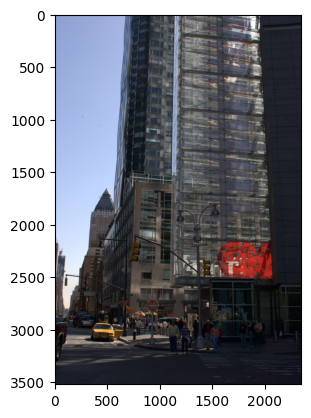

In [64]:
t_img = tf.io.read_file("/kaggle/input/datasets/weipengzhang/adobe-fivek/raw/a0012-kme_143.jpg")
t_img = tf.image.decode_jpeg(t_img)
t_img = tf.cast(t_img, tf.float32)
t_img = t_img / 255.0
plt.imshow(t_img.numpy())

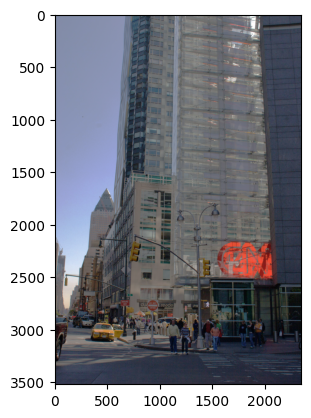

In [65]:
t_imgs = tf.stack([t_img])
t_luma = tf.constant([[0.0, 0.35, 0.5, 0.65, 1.0]]) # (1, 5)
t_color = tf.reshape(t_luma, [1,5,1])
t_color = tf.tile(t_color, [1,1,3])

t_out = curve_model([t_imgs, t_luma, t_color])[0]
plt.imshow(t_out.numpy())

In [33]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

def build_param_model(num_params):
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # EfficientNet expects 0–255
    x = inputs * 255.0
    x = eff_preprocess(x)

    backbone = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_tensor=x
    )
    backbone.trainable = False

    x = backbone.output
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dense(128, activation="relu")(x)

    K = num_params // 4
    identity = np.linspace(0.0, 1.0, K, dtype=np.float32)
    
    identity_full = np.concatenate([
        identity,  # luma
        identity,  # R
        identity,  # G
        identity   # B
    ])
    
    params = layers.Dense(
        num_params,
        activation="sigmoid",
        bias_initializer=tf.keras.initializers.Constant(identity_full)
    )(x)

    model = Model(inputs, params, name="param_net")

    return model, backbone

In [34]:
param_model, backbone = build_param_model(num_params=20)

## Losses

In [35]:
l1_fn = tf.keras.losses.MeanAbsoluteError()
l2_fn = tf.keras.losses.MeanSquaredError()

In [36]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

_vgg = VGG16(include_top=False, weights="imagenet")
_vgg.trainable = False

perceptual_model = tf.keras.Model(
    _vgg.input,
    _vgg.get_layer("block3_conv3").output
)
perceptual_model.trainable = False

def perceptual_loss(y_true, y_pred):
    # y_true, y_pred: [0,1]
    y_true_255 = y_true * 255.0
    y_pred_255 = y_pred * 255.0

    y_true_pp = vgg_preprocess(y_true_255)
    y_pred_pp = vgg_preprocess(y_pred_255)

    f_true = perceptual_model(y_true_pp)
    f_pred = perceptual_model(y_pred_pp)

    return tf.reduce_mean(tf.abs(f_true - f_pred))

In [37]:
def smooth_loss(lut):
    diff = lut[:, 1:] - lut[:, :-1]
    return tf.reduce_mean(tf.square(diff))

In [38]:
def smooth_loss_color(lut):
    diff = lut[:, 1:, :] - lut[:, :-1, :]
    return tf.reduce_mean(tf.square(diff))

In [39]:
def monotonic_loss(lut):
    diff = lut[:, 1:] - lut[:, :-1]
    penalty = tf.nn.relu(-diff)
    return tf.reduce_mean(penalty)

In [40]:
def monotonic_loss_color(lut):
    diff = lut[:, 1:, :] - lut[:, :-1, :]
    penalty = tf.nn.relu(-diff)
    return tf.reduce_mean(penalty)

In [41]:
def split_backbone_head(model, backbone):
    bb_vars = backbone.trainable_variables
    bb_ids = set(id(v) for v in bb_vars)

    head_vars = [
        v for v in model.trainable_variables
        if id(v) not in bb_ids
    ]
    return bb_vars, head_vars

In [42]:
backbone.trainable = False

backbone_vars_p1 = []
head_vars_p1 = param_model.trainable_variables

optimizer_head_p1 = tf.keras.optimizers.Adam(1e-3)
optimizer_head_p1.build(head_vars_p1)

In [43]:
backbone.trainable = True

backbone_vars_p2, head_vars_p2 = split_backbone_head(param_model, backbone)

optimizer_backbone_p2 = tf.keras.optimizers.Adam(1e-5)
optimizer_head_p2 = tf.keras.optimizers.Adam(1e-4)

optimizer_backbone_p2.build(backbone_vars_p2)
optimizer_head_p2.build(head_vars_p2)

In [44]:
num_params = 20
K = num_params // 4

def render_images(images, params):
    luma = params[:, :K]
    color = tf.reshape(params[:, K:], [-1, K, 3])
    outputs = curve_model([images, luma, color], training=False)
    return outputs, luma, color

In [45]:
@tf.function
def train_step_phase1(images, targets):
    with tf.GradientTape() as tape:
        params = param_model(images, training=True)
        outputs, _, _ = render_images(images, params)

        l1 = l1_fn(targets, outputs)
        l2 = l2_fn(targets, outputs)
        loss = l1 + 0.1 * l2

    grads = tape.gradient(loss, head_vars_p1)
    optimizer_head_p1.apply_gradients(zip(grads, head_vars_p1))

    return loss, l1, l2

In [46]:
@tf.function
def train_step_phase2(images, targets):
    with tf.GradientTape() as tape:
        params = param_model(images, training=True)
        outputs, luma, color = render_images(images, params)

        # ===== Loss components =====
        l1 = l1_fn(targets, outputs)
        p = perceptual_loss(targets, outputs)

        smooth = smooth_loss(luma) + smooth_loss_color(color)
        mono = monotonic_loss(luma) + monotonic_loss_color(color)

        loss = (
            l1
            + 0.1 * p
            + 0.01 * smooth
            + 0.005 * mono
        )

    grads = tape.gradient(loss, param_model.trainable_variables)

    bb_len = len(backbone_vars_p2)

    grads_backbone = grads[:bb_len]
    grads_head = grads[bb_len:]

    optimizer_backbone_p2.apply_gradients(zip(grads_backbone, backbone_vars_p2))
    optimizer_head_p2.apply_gradients(zip(grads_head, head_vars_p2))

    return loss, l1, p, smooth, mono

In [47]:
from tqdm.auto import tqdm

p1_history = {
    "loss": [],
    "l1": [],
    "l2": []
}

num_epochs = 2

for epoch in range(num_epochs):
    print(f"\nPhase-1 Epoch {epoch+1}/{num_epochs}")

    pbar = tqdm(train_ds, desc="P1 training", leave=False)

    total_loss = 0.0
    total_l1 = 0.0
    total_l2 = 0.0
    steps = 0

    for img, tgt in pbar:
        loss, l1, l2 = train_step_phase1(img, tgt)

        loss_v = loss.numpy()
        l1_v = l1.numpy()
        l2_v = l2.numpy()

        total_loss += loss_v
        total_l1 += l1_v
        total_l2 += l2_v
        steps += 1

        # running mean để nhìn ổn định hơn
        pbar.set_postfix({
            "loss": f"{total_loss/steps:.4f}",
            "l1": f"{total_l1/steps:.4f}",
            "l2": f"{total_l2/steps:.4f}"
        })

    # mean epoch
    mean_loss = total_loss / steps
    mean_l1 = total_l1 / steps
    mean_l2 = total_l2 / steps

    p1_history["loss"].append(mean_loss)
    p1_history["l1"].append(mean_l1)
    p1_history["l2"].append(mean_l2)

    print(f"P1 Epoch {epoch+1} | loss={mean_loss:.4f} | l1={mean_l1:.4f} | l2={mean_l2:.4f}")


Phase-1 Epoch 1/2


P1 training:   0%|          | 0/563 [00:00<?, ?it/s]

E0000 00:00:1772424736.648303     394 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inparam_net_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1772424737.983147     451 cuda_dnn.cc:529] Loaded cuDNN version 91002


P1 Epoch 1 | loss=0.1059 | l1=0.1039 | l2=0.0200

Phase-1 Epoch 2/2


P1 training:   0%|          | 0/563 [00:00<?, ?it/s]

P1 Epoch 2 | loss=0.0915 | l1=0.0900 | l2=0.0152


In [49]:
from tqdm.auto import tqdm

p2_history = {
    "loss": [],
    "l1": [],
    "perceptual": [],
    "smooth": [],
    "mono": []
}

num_epochs = 5

for epoch in range(num_epochs):
    print(f"\nPhase-2 Epoch {epoch+1}/{num_epochs}")

    pbar = tqdm(train_ds, desc="P2 training", leave=False)

    total_loss = 0.0
    total_l1 = 0.0
    total_p = 0.0
    total_s = 0.0
    total_m = 0.0
    steps = 0

    for img, tgt in pbar:
        loss, l1, p, s, m = train_step_phase2(img, tgt)

        loss_v = loss.numpy()
        l1_v = l1.numpy()
        p_v = p.numpy()
        s_v = s.numpy()
        m_v = m.numpy()

        total_loss += loss_v
        total_l1 += l1_v
        total_p += p_v
        total_s += s_v
        total_m += m_v
        steps += 1

        pbar.set_postfix({
            "loss": f"{total_loss/steps:.4f}",
            "L1": f"{total_l1/steps:.4f}",
            "P": f"{total_p/steps:.4f}"
        })

    # mean epoch
    mean_loss = total_loss / steps
    mean_l1 = total_l1 / steps
    mean_p = total_p / steps
    mean_s = total_s / steps
    mean_m = total_m / steps

    # lưu history
    p2_history["loss"].append(mean_loss)
    p2_history["l1"].append(mean_l1)
    p2_history["perceptual"].append(mean_p)
    p2_history["smooth"].append(mean_s)
    p2_history["mono"].append(mean_m)

    print(
        f"P2 Epoch {epoch+1} | "
        f"loss={mean_loss:.4f} "
        f"L1={mean_l1:.4f} "
        f"P={mean_p:.4f} "
        f"S={mean_s:.4f} "
        f"M={mean_m:.4f}"
    )


Phase-2 Epoch 1/5


P2 training:   0%|          | 0/563 [00:00<?, ?it/s]

E0000 00:00:1772425201.960531     394 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inparam_net_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
E0000 00:00:1772425319.645246     394 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inparam_net_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


P2 Epoch 1 | loss=8.1633 L1=0.0832 P=80.7901 S=0.1101 M=0.0000

Phase-2 Epoch 2/5


P2 training:   0%|          | 0/563 [00:00<?, ?it/s]

...

P2 Epoch 3 | loss=7.8220 L1=0.0801 P=77.4076 S=0.1110 M=0.0000

Phase-2 Epoch 4/5


P2 training:   0%|          | 0/563 [00:00<?, ?it/s]

P2 Epoch 4 | loss=7.7586 L1=0.0796 P=76.7782 S=0.1118 M=0.0000

Phase-2 Epoch 5/5


P2 training:   0%|          | 0/563 [00:00<?, ?it/s]

P2 Epoch 5 | loss=7.7147 L1=0.0786 P=76.3499 S=0.1126 M=0.0000


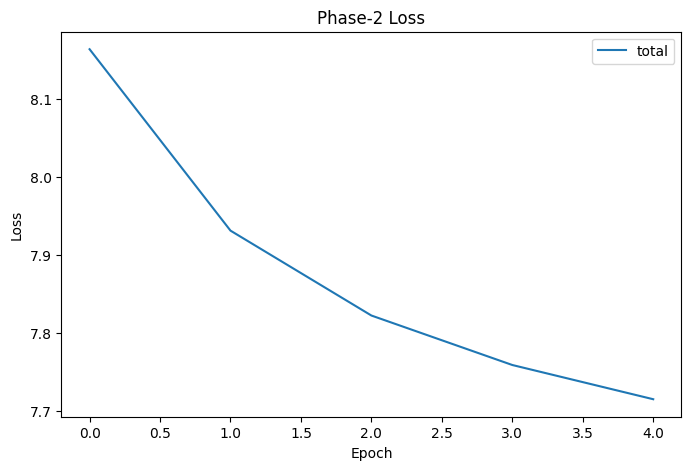

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(p2_history["loss"], label="total")
# plt.plot(p2_history["l1"], label="L1")
# plt.plot(p2_history["perceptual"], label="Perceptual")
# plt.plot(p2_history["smooth"], label="Smooth")
# plt.plot(p2_history["mono"], label="Monotonic")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Phase-2 Loss")
plt.legend()
plt.show()

## Evaluate

In [51]:
@tf.function
def test_step(images, targets):
    # predict params
    params = param_model(images, training=False)

    # tách LUT
    K = params.shape[1] // 4
    luma_lut = params[:, :K]
    color_lut = tf.reshape(params[:, K:], [-1, K, 3])

    # apply curve
    preds = curve_model([images, luma_lut, color_lut], training=False)

    # losses
    l1 = tf.reduce_mean(tf.abs(preds - targets))
    p = perceptual_loss(targets, preds)
    s = smooth_loss(luma_lut) + smooth_loss_color(color_lut)
    m = monotonic_loss(luma_lut) + monotonic_loss_color(color_lut)

    total = l1 + 0.05*p + 0.02*s + 0.005*m

    return total, l1, p, s, m

In [52]:
from tqdm.auto import tqdm

def evaluate(test_ds):
    total_loss = 0.0
    total_l1 = 0.0
    total_p = 0.0
    total_s = 0.0
    total_m = 0.0
    steps = 0

    pbar = tqdm(test_ds, desc="Testing", leave=False)

    for img, tgt in pbar:
        loss, l1, p, s, m = test_step(img, tgt)

        loss_v = loss.numpy()
        l1_v = l1.numpy()
        p_v = p.numpy()
        s_v = s.numpy()
        m_v = m.numpy()

        total_loss += loss_v
        total_l1 += l1_v
        total_p += p_v
        total_s += s_v
        total_m += m_v
        steps += 1

        pbar.set_postfix({
            "loss": f"{total_loss/steps:.4f}",
            "L1": f"{total_l1/steps:.4f}"
        })

    return {
        "loss": total_loss / steps,
        "l1": total_l1 / steps,
        "perceptual": total_p / steps,
        "smooth": total_s / steps,
        "mono": total_m / steps
    }

In [53]:
evaluate(test_ds)

Testing:   0%|          | 0/63 [00:00<?, ?it/s]

{'loss': np.float32(4.2453394),
 'l1': np.float32(0.08816329),
 'perceptual': np.float32(83.09808),
 'smooth': np.float32(0.11360427),
 'mono': np.float32(0.0)}

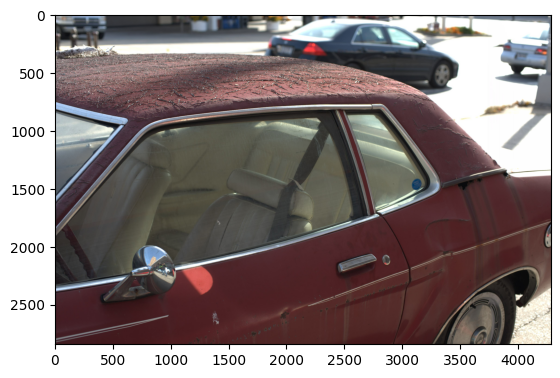

In [54]:
t_img = tf.io.read_file("/kaggle/input/datasets/weipengzhang/adobe-fivek/raw/a0024-_DSC8932.jpg")
t_img = tf.image.decode_jpeg(t_img)
t_img = tf.cast(t_img, tf.float32)
t_img = t_img / 255.0
plt.imshow(t_img.numpy())

In [55]:
t_img_rs = tf.image.resize(t_img, [IMG_SIZE, IMG_SIZE])
# plt.imshow(t_img_rs)

In [56]:
t_params = param_model(tf.stack([t_img_rs]))
t_params

<tf.Tensor: shape=(1, 20), dtype=float32, numpy=
array([[7.5196240e-06, 2.2661744e-01, 5.1769334e-01, 7.5930315e-01,
        9.9987948e-01, 4.1242424e-04, 2.8971580e-04, 1.0129749e-03,
        2.3818633e-01, 2.4770533e-01, 2.6122621e-01, 5.1598907e-01,
        5.2170658e-01, 5.5678356e-01, 6.6567677e-01, 7.6429331e-01,
        7.6832938e-01, 8.7415260e-01, 8.7238735e-01, 8.7067401e-01]],
      dtype=float32)>

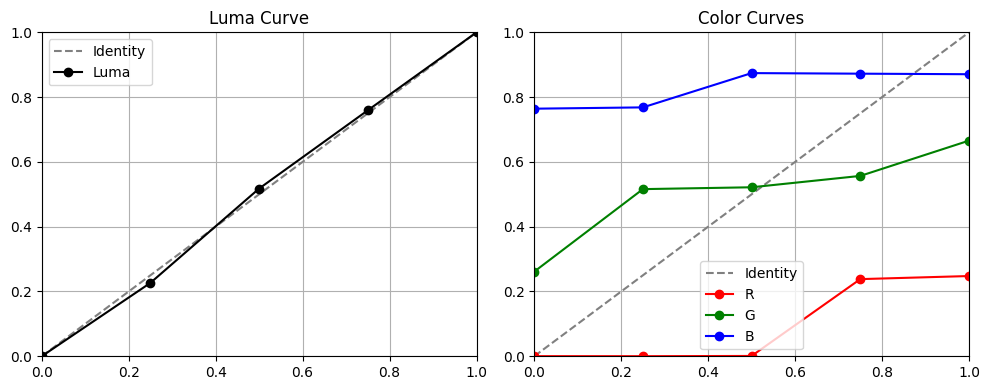

In [62]:
import numpy as np
import matplotlib.pyplot as plt

params = t_params[0].numpy()

luma = params[:5]
color = params[5:].reshape(3, 5)  # (R, G, B)

r_curve = color[0]
g_curve = color[1]
b_curve = color[2]

x = np.linspace(0, 1, 5)

# Identity line (đường gốc)
identity = x

# ---- Plot ----
plt.figure(figsize=(10,4))

# ---- Luma ----
plt.subplot(1,2,1)
plt.plot(x, identity, color='gray', linestyle='--', label='Identity')
plt.plot(x, luma, 'k-o', label='Luma')
plt.title("Luma Curve")
plt.xlim(0,1)
plt.ylim(0,1)
plt.grid()
plt.legend()

# ---- RGB ----
plt.subplot(1,2,2)
plt.plot(x, identity, color='gray', linestyle='--', label='Identity')
plt.plot(x, r_curve, 'r-o', label='R')
plt.plot(x, g_curve, 'g-o', label='G')
plt.plot(x, b_curve, 'b-o', label='B')
plt.title("Color Curves")
plt.xlim(0,1)
plt.ylim(0,1)
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [57]:
outputs, luma, color = render_images(tf.stack([t_img]), t_params)

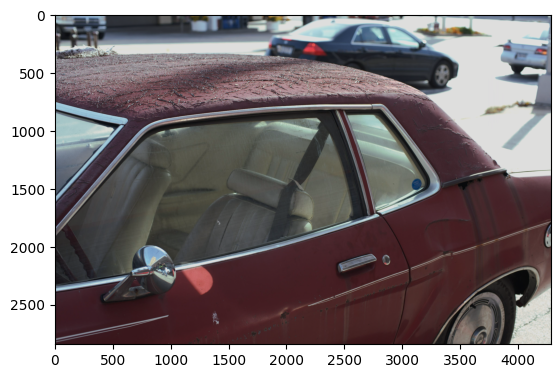

In [58]:
plt.imshow(outputs[0].numpy())

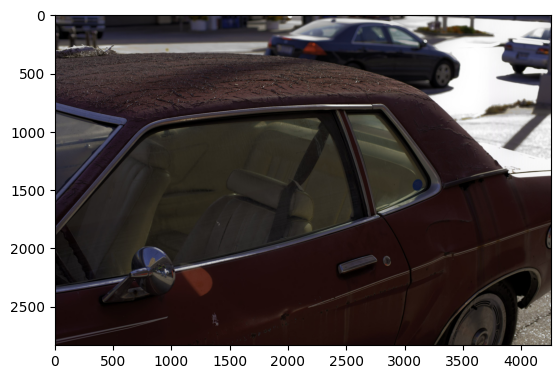

In [59]:
tt_img = tf.io.read_file("/kaggle/input/datasets/weipengzhang/adobe-fivek/c/a0024-_DSC8932.jpg")
tt_img = tf.image.decode_jpeg(tt_img)
tt_img = tf.cast(tt_img, tf.float32)
tt_img = tt_img / 255.0
plt.imshow(tt_img.numpy())

# Export model

In [67]:
param_model.export("param_saved")

INFO:tensorflow:Assets written to: param_saved/assets


INFO:tensorflow:Assets written to: param_saved/assets


Saved artifact at 'param_saved'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_245')
Output Type:
  TensorSpec(shape=(None, 20), dtype=tf.float32, name=None)
Captures:
  137552864398608: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  137552864399376: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  137552869402448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137552869402064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137552869401872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137552869400912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137552869402832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137552869401680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137552869401104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137552869402640: TensorSpec(shape=(), dtype=tf.resource, name=None

In [68]:
curve_model.export("curve_saved")

INFO:tensorflow:Assets written to: curve_saved/assets


INFO:tensorflow:Assets written to: curve_saved/assets


Saved artifact at 'curve_saved'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, None, None, 3), dtype=tf.float32, name='image'), TensorSpec(shape=(None, 5), dtype=tf.float32, name='luma_lut'), TensorSpec(shape=(None, 5, 3), dtype=tf.float32, name='color_lut')]
Output Type:
  TensorSpec(shape=(None, None, None, 3), dtype=tf.float32, name=None)
Captures:
  None


In [70]:
!pip install tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.3 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 25.0
    Uninstalling packaging-25.0:
      Successfully uninstalled packaging-25.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ray 2.53.0 requires packaging>=24.2, but you have packaging 23.2 which is incompatible.
build 1.4.0 requires packaging>=24.0, but you have packaging 23.2 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==

In [71]:
!ls param_saved

assets	fingerprint.pb	saved_model.pb	variables


In [72]:
!ls curve_saved

assets	fingerprint.pb	saved_model.pb	variables


In [73]:
!tensorflowjs_converter \
  --input_format=tf_saved_model \
  --output_format=tfjs_graph_model \
  param_saved \
  param_tfjs

2026-03-02 05:01:24.181111: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772427684.202676     766 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772427684.209146     766 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772427684.226479     766 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772427684.226513     766 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772427684.226519     766 computation_placer.cc:177] computation placer alr

In [74]:
!tensorflowjs_converter \
  --input_format=tf_saved_model \
  --output_format=tfjs_graph_model \
  curve_saved \
  curve_tfjs

2026-03-02 05:01:43.440418: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772427703.461975     811 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772427703.469637     811 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772427703.486231     811 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772427703.486261     811 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772427703.486265     811 computation_placer.cc:177] computation placer alr

In [75]:
!ls param_tfjs
!ls curve_tfjs

group1-shard1of5.bin  group1-shard3of5.bin  group1-shard5of5.bin
group1-shard2of5.bin  group1-shard4of5.bin  model.json
group1-shard1of1.bin  model.json


In [76]:
!zip -r param_tfjs.zip param_tfjs

  adding: param_tfjs/ (stored 0%)
  adding: param_tfjs/group1-shard5of5.bin (deflated 8%)
  adding: param_tfjs/group1-shard1of5.bin (deflated 7%)
  adding: param_tfjs/group1-shard4of5.bin (deflated 7%)
  adding: param_tfjs/group1-shard2of5.bin (deflated 7%)
  adding: param_tfjs/group1-shard3of5.bin (deflated 7%)
  adding: param_tfjs/model.json (deflated 96%)


In [77]:
!zip -r curve_tfjs.zip curve_tfjs

  adding: curve_tfjs/ (stored 0%)
  adding: curve_tfjs/group1-shard1of1.bin (deflated 68%)
  adding: curve_tfjs/model.json (deflated 94%)
